Causal inference workflow for alloy processing–structure–property relationships

This script implements a data-driven causal discovery pipeline to identify
directional relationships among processing, composition, microstructure,
and mechanical properties in Pt–Au alloys.

Workflow:
1. Load experimental dataset and define variable groups
   (processing, composition, microstructure, property).
2. Perform pairwise causal analysis using symbolic regression to model
   functional relationships between variables.
3. Compute residual independence using the Hilbert–Schmidt Independence Criterion (HSIC)
   to evaluate causal direction based on the additive noise model (ANM) framework.
4. Determine causal direction by comparing HSIC values in both directions
   and applying independence thresholds.
5. Aggregate all pairwise results into causal matrices and visualize
   the inferred causal structure.

Notes:
- Symbolic regression is used as a flexible, nonparametric regressor to capture
  nonlinear relationships between variables.
- Causal direction is inferred by testing independence between inputs and residuals,
  following the ANM principle.
- All pairwise analyses are performed deterministically to ensure reproducibility.

Author: Quan Li; quan.li@mpi-susmat.de

In [ ]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pysr import PySRRegressor


# ============================================================
# 0. User settings
# ============================================================
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd()

FILE_PATH = PROJECT_ROOT / "data" / "Dataset_PtAu.xlsx"
SHEET_NAME = "Anneal_Punch"

SAVE_RESULTS = True
OUTPUT_ROOT = PROJECT_ROOT / "Causal_results"
FIGURE_DPI = 300

NPROCS = 1  # keep serial/deterministic behavior for reproducibility

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not FILE_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {FILE_PATH}\n"
        "Expected location: <project_root>/data/dataset_ptau.xlsx"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {FILE_PATH}")
print(f"Output directory: {OUTPUT_ROOT}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Project root: d:\Research\PtAu\Manuscript\20260322-Submitted_Nature
Using dataset: D:\Research\PtAu\Manuscript\20260322-Submitted_Nature\Dataset_PtAu.xlsx
Output directory: d:\Research\PtAu\Manuscript\20260322-Submitted_Nature\results


In [2]:
# ============================================================
# 1. Load dataset
# ============================================================
xls = pd.ExcelFile(FILE_PATH, engine="openpyxl")
if SHEET_NAME not in xls.sheet_names:
    raise ValueError(
        f"Sheet '{SHEET_NAME}' not found in {FILE_PATH.name}. "
        f"Available sheets: {xls.sheet_names}"
    )

df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="openpyxl")
print("\nLoaded dataframe shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))


Loaded dataframe shape: (396, 10)
Columns: ['Data No.', 'anneal', 'punch', 'grain size', 'Au in grain', 'Au at gb', 'Pt in grain', 'Pt at gb', 'dislocation density', 'hardness']


In [3]:
# ============================================================
# 2. Variable labels and group definitions
# ============================================================
variable_labels = [
    "Anneal time",
    "Punch depth",
    "Au in grain",
    "Au at GB",
    "Grain size",
    "Dislocation density",
    "Hardness",
]

label_to_col = {
    "Anneal time": "anneal",
    "Punch depth": "punch",
    "Au in grain": "Au in grain",
    "Au at GB": "Au at gb",
    "Grain size": "grain size",
    "Dislocation density": "dislocation density",
    "Hardness": "hardness",
}

groups = {
    "Processing": ["Anneal time", "Punch depth"],
    "Composition": ["Au in grain", "Au at GB"],
    "Microstructure": ["Grain size", "Dislocation density"],
    "Property": ["Hardness"],
}

In [4]:
# ============================================================
# 3. Data validation and cleaning
# ============================================================
required_cols = [label_to_col[label] for label in variable_labels]

missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns in dataset: {missing_cols}\n"
        f"Required columns: {required_cols}"
    )

df = df_raw[required_cols].dropna().copy()
print("\nCleaned dataframe shape:", df.shape)
print("Retained columns:", required_cols)


Cleaned dataframe shape: (396, 7)
Retained columns: ['anneal', 'punch', 'Au in grain', 'Au at gb', 'grain size', 'dislocation density', 'hardness']


In [5]:
# ============================================================
# 4. Symbolic regression helper
# ============================================================
def symbolic_regressor(X, y, sr_config=None):
    """
    Fit symbolic regression and return predictions and fitted model.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()

    if X.ndim == 1:
        X = X[:, np.newaxis]

    if sr_config is None:
        sr_config = {}

    sr_model = PySRRegressor(
        model_selection=sr_config.get("model_selection", "best"),
        niterations=sr_config.get("niterations", 200),
        binary_operators=sr_config.get("binary_operators", ["+", "-", "*"]),
        unary_operators=sr_config.get("unary_operators", ["log"]),
        populations=sr_config.get("populations", 5),
        population_size=sr_config.get("population_size", 20),
        maxdepth=sr_config.get("maxdepth", 5),
        verbosity=sr_config.get("verbosity", 0),
        turbo=sr_config.get("turbo", True),
        progress=sr_config.get("progress", False),
        random_state=sr_config.get("random_state", 0),
        deterministic=sr_config.get("deterministic", True),
        parallelism="serial",
        
    )

    sr_model.fit(X, y)
    y_pred = sr_model.predict(X)
    return y_pred, sr_model

In [6]:
# ============================================================
# 5. HSIC independence test
# ============================================================
def estimate_sigma(X, sigma_scale=1.0):
    """
    Median heuristic for RBF kernel width.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[:, np.newaxis]

    G = np.sum(X * X, axis=1)[:, np.newaxis]
    Q = np.tile(G, (1, X.shape[0]))
    dists = Q + Q.T - 2 * np.dot(X, X.T)
    dists = dists - np.tril(dists)
    dists = dists.flatten()
    dists = dists[dists > 0]

    if dists.size == 0:
        base_sigma = 1.0
    else:
        base_sigma = np.sqrt(0.5 * np.median(dists))

    return sigma_scale * base_sigma


def rbf_kernel(X1, X2, sigma):
    """
    RBF kernel matrix.
    """
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)

    if X1.ndim == 1:
        X1 = X1[:, np.newaxis]
    if X2.ndim == 1:
        X2 = X2[:, np.newaxis]

    G = np.sum(X1 * X1, axis=1)[:, np.newaxis]
    H = np.sum(X2 * X2, axis=1)[:, np.newaxis]
    Q = np.tile(G, (1, X2.shape[0]))
    R = np.tile(H.T, (X1.shape[0], 1))
    K = Q + R - 2 * np.dot(X1, X2.T)
    return np.exp(-K / (2 * sigma**2 + 1e-12))


def hsic_test(
    X,
    Y,
    auto_scale=True,
    std_ratio_low=1.0,
    std_ratio_high=5.0,
    sigma_scale_norm=1.0,
    sigma_scale_raw=1.0,
):
    """
    Compute HSIC between X and Y using RBF kernels.
    Optionally normalize if the two variables have very different scales.
    """
    X = np.asarray(X, dtype=float).ravel()
    Y = np.asarray(Y, dtype=float).ravel()

    normalized_flag = False

    if auto_scale:
        std_x = np.std(X)
        std_y = np.std(Y)
        std_x_safe = max(std_x, 1e-12)
        std_y_safe = max(std_y, 1e-12)
        std_ratio = std_x_safe / std_y_safe

        if std_ratio >= std_ratio_high or std_ratio < std_ratio_low:
            X = (X - X.mean()) / std_x_safe
            Y = (Y - Y.mean()) / std_y_safe
            normalized_flag = True

    X = X[:, np.newaxis]
    Y = Y[:, np.newaxis]
    n = X.shape[0]

    sigma_scale = sigma_scale_norm if normalized_flag else sigma_scale_raw

    width_x = estimate_sigma(X, sigma_scale=sigma_scale)
    width_y = estimate_sigma(Y, sigma_scale=sigma_scale)

    H = np.eye(n) - np.ones((n, n)) / n
    K = rbf_kernel(X, X, width_x)
    L = rbf_kernel(Y, Y, width_y)

    Kc = H @ K @ H
    Lc = H @ L @ H

    hsic = np.mean(Kc * Lc)
    hsic = max(hsic, 0.0)

    return hsic, normalized_flag

In [7]:
# ============================================================
# 6. Pairwise causal direction evaluation
# ============================================================
def evaluate_pair(
    x,
    y,
    x_name="x",
    y_name="y",
    sr_config=None,
    hsic_config=None,
    decision_config=None,
):
    """
    Evaluate causal direction between x and y by:
    - fitting x -> y and y -> x with symbolic regression
    - computing residual dependence via HSIC
    - choosing the direction with smaller HSIC
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    if sr_config is None:
        sr_config = {}
    if hsic_config is None:
        hsic_config = {}
    if decision_config is None:
        decision_config = {}

    ind_threshold = decision_config.get("ind_threshold", 1e-3)

    # X -> Y
    y_pred_xy, model_xy = symbolic_regressor(x, y, sr_config)
    residual_xy = y_pred_xy - y
    std_eps_xy = np.std(residual_xy)
    std_x = np.std(x)
    std_ratio_xy = std_eps_xy / (std_x + 1e-12)
    hsic_xy, norm_xy = hsic_test(residual_xy, x, **hsic_config)

    # Y -> X
    y_pred_yx, model_yx = symbolic_regressor(y, x, sr_config)
    residual_yx = y_pred_yx - x
    std_eps_yx = np.std(residual_yx)
    std_y = np.std(y)
    std_ratio_yx = std_eps_yx / (std_y + 1e-12)
    hsic_yx, norm_yx = hsic_test(residual_yx, y, **hsic_config)

    diff = hsic_xy - hsic_yx

    if np.isnan(hsic_xy) or np.isnan(hsic_yx):
        decision = "NaN"
        direction = None
    elif hsic_xy < ind_threshold and hsic_yx < ind_threshold:
        decision = "independent"
        direction = None
    elif hsic_xy < hsic_yx:
        decision = "directed"
        direction = f"{x_name} --> {y_name}"
    else:
        decision = "directed"
        direction = f"{y_name} --> {x_name}"

    result = {
        "x_name": x_name,
        "y_name": y_name,
        "regressor": "sr",
        "ind_threshold": ind_threshold,
        "std_x": std_x,
        "std_y": std_y,
        "std_eps_xy": std_eps_xy,
        "std_eps_yx": std_eps_yx,
        "std_ratio_xy": std_ratio_xy,
        "std_ratio_yx": std_ratio_yx,
        "hsic_xy": hsic_xy,
        "hsic_yx": hsic_yx,
        "hsic_diff": diff,
        "norm_xy": norm_xy,
        "norm_yx": norm_yx,
        "decision": decision,
        "direction": direction,
        "expr_xy": str(model_xy.get_best()) if model_xy is not None else None,
        "expr_yx": str(model_yx.get_best()) if model_yx is not None else None,
    }

    print(f"\nAnalyzing pair: {x_name} - {y_name}")
    print(
        f"HSIC(x→y): {hsic_xy:.6f}, "
        f"HSIC(y→x): {hsic_yx:.6f}, "
        f"Difference: {diff:.6f}"
    )

    if decision == "independent":
        print("Decision: Independence (⊥)")
    elif decision == "directed":
        print(f"Decision: {direction}")
    else:
        print("Decision: NaN / invalid (check data)")

    return result


def analyze_pair(
    x_label,
    y_label,
    df,
    label_to_col,
    sr_config=None,
    hsic_config=None,
    decision_config=None,
    results_list=None,
):
    """
    Wrapper that maps display labels to dataframe columns.
    """
    if x_label not in label_to_col:
        raise ValueError(f"x_label '{x_label}' not in label_to_col")
    if y_label not in label_to_col:
        raise ValueError(f"y_label '{y_label}' not in label_to_col")

    x_col = label_to_col[x_label]
    y_col = label_to_col[y_label]

    x = df[x_col].values
    y = df[y_col].values

    result = evaluate_pair(
        x,
        y,
        x_name=x_label,
        y_name=y_label,
        sr_config=sr_config,
        hsic_config=hsic_config,
        decision_config=decision_config,
    )

    if results_list is not None:
        results_list.append(result)

    return result

In [8]:
# ============================================================
# 7. Configuration helpers
# ============================================================
def make_hsic_config(
    base,
    sigma_norm=1.0,
    sigma_raw=1.0,
    std_ratio_low=None,
    std_ratio_high=None,
    auto_scale=None,
):
    cfg = base.copy()
    cfg["sigma_scale_norm"] = sigma_norm
    cfg["sigma_scale_raw"] = sigma_raw

    if std_ratio_low is not None:
        cfg["std_ratio_low"] = std_ratio_low
    if std_ratio_high is not None:
        cfg["std_ratio_high"] = std_ratio_high
    if auto_scale is not None:
        cfg["auto_scale"] = auto_scale

    return cfg


default_sr_params = {
    "model_selection": "best",
    "niterations": 200,
    "binary_operators": ["+", "-", "*"],
    "unary_operators": ["log"],
    "populations": 5,
    "population_size": 20,
    "maxdepth": 5,
    "verbosity": 0,
    "turbo": True,
    "progress": False,
    "random_state": 0,
    "deterministic": True,
    "parallelism": "serial",
    "procs": NPROCS,
}

default_hsic_params = {
    "auto_scale": True,
    "std_ratio_low": 1.0,
    "std_ratio_high": 5.0,
    "sigma_scale_norm": 1.0,
    "sigma_scale_raw": 1.0,
}

default_decision_params = {
    "ind_threshold": 1e-3,
}

In [9]:

# ============================================================
# 8. Pair definitions
# ============================================================
pair_configs = [
    ("Anneal time", "Punch depth", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Anneal time", "Au in grain", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Anneal time", "Au at GB", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Anneal time", "Grain size", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Anneal time", "Dislocation density", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=3.0, std_ratio_low=1e-11, std_ratio_high=1e14)),
    ("Anneal time", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),

    ("Punch depth", "Au in grain", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Punch depth", "Au at GB", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Punch depth", "Grain size", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Punch depth", "Dislocation density", make_hsic_config(default_hsic_params, sigma_norm=0.5, sigma_raw=1.0)),
    ("Punch depth", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=0.5, sigma_raw=1.0)),

    ("Au in grain", "Au at GB", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),
    ("Au in grain", "Grain size", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=2.0, std_ratio_low=1e-2, std_ratio_high=1e2)),
    ("Au in grain", "Dislocation density", make_hsic_config(default_hsic_params, sigma_norm=2.0, sigma_raw=1.0)),
    ("Au in grain", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0)),

    ("Au at GB", "Grain size", make_hsic_config(default_hsic_params, sigma_norm=3.0, sigma_raw=0.2, std_ratio_low=0.1, std_ratio_high=0.5)),
    ("Au at GB", "Dislocation density", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=5.0, std_ratio_low=1e-12, std_ratio_high=1e13)),
    ("Au at GB", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=3.0, sigma_raw=0.5, std_ratio_low=1e-1, std_ratio_high=5.0)),

    ("Grain size", "Dislocation density", make_hsic_config(default_hsic_params, sigma_norm=5.0, sigma_raw=1.0, std_ratio_low=0.1, std_ratio_high=5.0)),
    ("Grain size", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0, std_ratio_low=1e-3, std_ratio_high=10.0)),

    ("Dislocation density", "Hardness", make_hsic_config(default_hsic_params, sigma_norm=1.0, sigma_raw=1.0, std_ratio_low=1e-15, std_ratio_high=1e14)),
]

In [10]:
# ============================================================
# 9. Run pairwise analysis
# ============================================================
results = []

for x_label, y_label, hsic_cfg in pair_configs:
    analyze_pair(
        x_label=x_label,
        y_label=y_label,
        df=df,
        label_to_col=label_to_col,
        sr_config=default_sr_params,
        hsic_config=hsic_cfg,
        decision_config=default_decision_params,
        results_list=results,
    )

results_df = pd.DataFrame(results)
print("\nPairwise results preview:")
print(results_df.head())


Analyzing pair: Anneal time - Punch depth
HSIC(x→y): 0.000020, HSIC(y→x): 0.000150, Difference: -0.000131
Decision: Independence (⊥)

Analyzing pair: Anneal time - Au in grain
HSIC(x→y): 0.009952, HSIC(y→x): 0.034468, Difference: -0.024516
Decision: Anneal time --> Au in grain

Analyzing pair: Anneal time - Au at GB
HSIC(x→y): 0.004974, HSIC(y→x): 0.071744, Difference: -0.066770
Decision: Anneal time --> Au at GB

Analyzing pair: Anneal time - Grain size
HSIC(x→y): 0.003694, HSIC(y→x): 0.061788, Difference: -0.058093
Decision: Anneal time --> Grain size

Analyzing pair: Anneal time - Dislocation density
HSIC(x→y): 0.010984, HSIC(y→x): 0.045362, Difference: -0.034378
Decision: Anneal time --> Dislocation density

Analyzing pair: Anneal time - Hardness
HSIC(x→y): 0.000648, HSIC(y→x): 0.068017, Difference: -0.067369
Decision: Anneal time --> Hardness

Analyzing pair: Punch depth - Au in grain
HSIC(x→y): 0.000077, HSIC(y→x): 0.000076, Difference: 0.000000
Decision: Independence (⊥)

Analy

In [11]:
# ============================================================
# 10. Build matrices from results
# ============================================================
def build_matrices_from_results(results, label_order):
    """
    Convert result dictionaries into matrices for plotting.
    """
    n = len(label_order)
    name_to_idx = {name: i for i, name in enumerate(label_order)}

    hsic_diff_mat = np.full((n, n), np.nan)
    hsic_xy_mat = np.full((n, n), np.nan)
    hsic_yx_mat = np.full((n, n), np.nan)

    direction_mat = np.zeros((n, n))
    indep_mat = np.zeros((n, n), dtype=int)
    ambig_mat = np.zeros((n, n), dtype=int)

    for r in results:
        x_name = r["x_name"]
        y_name = r["y_name"]

        if x_name not in name_to_idx or y_name not in name_to_idx:
            continue

        i = name_to_idx[x_name]
        j = name_to_idx[y_name]

        hsic_xy_mat[j, i] = r["hsic_xy"]
        hsic_yx_mat[j, i] = r["hsic_yx"]
        hsic_diff_mat[j, i] = r["hsic_diff"]

        decision = r.get("decision", None)
        direction = r.get("direction", None)

        if decision == "independent":
            indep_mat[j, i] = 1
        elif decision == "ambiguous":
            ambig_mat[j, i] = 1
        elif decision == "directed" and direction is not None:
            if direction == f"{x_name} --> {y_name}":
                direction_mat[j, i] = -1.0
            elif direction == f"{y_name} --> {x_name}":
                direction_mat[j, i] = +1.0

    return hsic_diff_mat, hsic_xy_mat, hsic_yx_mat, direction_mat, indep_mat, ambig_mat

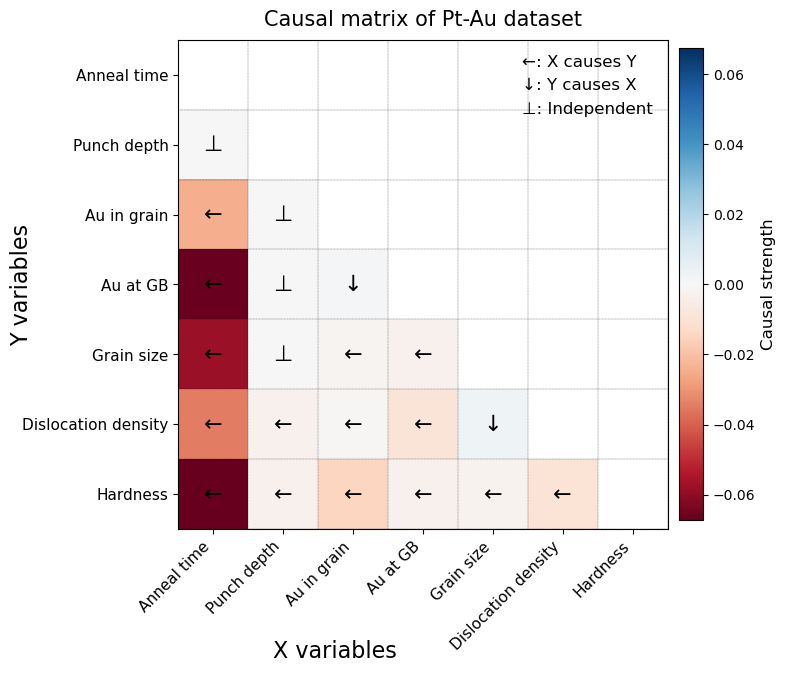

In [12]:
# ============================================================
# 11. Plot causal matrix
# ============================================================
def plot_causal_lower_triangle_only(
    hsic_diff_mat,
    direction_mat,
    indep_mat,
    ambig_mat,
    labels,
    title="Causal matrix of Pt-Au dataset",
    save_path=None,
):
    """
    Plot lower-triangular causal matrix with arrow/symbol annotations.
    """
    n = len(labels)
    mat = hsic_diff_mat.copy()

    for j in range(n):
        for i in range(n):
            if j <= i:
                mat[j, i] = np.nan

    fig, ax = plt.subplots(figsize=(8, 7))

    absmax = np.nanmax(np.abs(mat))
    if not np.isfinite(absmax) or absmax == 0:
        absmax = 1.0

    im = ax.imshow(mat, cmap="RdBu", vmin=-absmax, vmax=absmax)

    for (j, i), diff in np.ndenumerate(mat):
        if j <= i or np.isnan(diff):
            continue

        if indep_mat[j, i] == 1:
            txt = "⊥"
        elif ambig_mat[j, i] == 1:
            txt = "?"
        else:
            dir_flag = direction_mat[j, i]
            if dir_flag == -1:
                txt = "←"
            elif dir_flag == +1:
                txt = "↓"
            else:
                txt = ""

        ax.text(i, j, txt, ha="center", va="center", color="black", fontsize=16)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, fontsize=11, rotation=45, ha="right")
    ax.set_yticklabels(labels, fontsize=11)

    ax.set_xticks(np.arange(n) + 0.5, minor=True)
    ax.set_yticks(np.arange(n) + 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle="--", linewidth=0.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.text(
        0.32, -0.25,
        "X variables",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16
    )

    ax.text(
        -0.32, 0.5,
        "Y variables",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16,
        rotation=90
    )

    cbar = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
    cbar.set_label("Causal strength", fontsize=12)

    legend_elements = [
        plt.Line2D([0], [0], marker="", color="none", label="←: X causes Y"),
        plt.Line2D([0], [0], marker="", color="none", label="↓: Y causes X"),
        plt.Line2D([0], [0], marker="", color="none", label="⊥: Independent"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.00),
        frameon=False,
        fontsize=12
    )

    ax.set_title(title, fontsize=15, pad=10)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")

    plt.show()


(
    hsic_diff_mat,
    hsic_xy_mat,
    hsic_yx_mat,
    direction_mat,
    indep_mat,
    ambig_mat,
) = build_matrices_from_results(results, variable_labels)

figure_path = OUTPUT_ROOT / "causal_matrix_ptau.png" if SAVE_RESULTS else None

plot_causal_lower_triangle_only(
    hsic_diff_mat=hsic_diff_mat,
    direction_mat=direction_mat,
    indep_mat=indep_mat,
    ambig_mat=ambig_mat,
    labels=variable_labels,
    title="Causal matrix of Pt-Au dataset",
    save_path=figure_path,
)

In [13]:

# ============================================================
# 12. Save tabular outputs
# ============================================================
if SAVE_RESULTS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    results_csv = OUTPUT_ROOT / f"causal_pairwise_results_{timestamp}.csv"
    results_df.to_csv(results_csv, index=False)

    hsic_diff_csv = OUTPUT_ROOT / f"causal_hsic_diff_matrix_{timestamp}.csv"
    pd.DataFrame(hsic_diff_mat, index=variable_labels, columns=variable_labels).to_csv(hsic_diff_csv)

    direction_csv = OUTPUT_ROOT / f"causal_direction_matrix_{timestamp}.csv"
    pd.DataFrame(direction_mat, index=variable_labels, columns=variable_labels).to_csv(direction_csv)

    print("\nSaved outputs:")
    print(results_csv)
    print(hsic_diff_csv)
    print(direction_csv)

print("\nCausal inference workflow completed successfully.")


Saved outputs:
d:\Research\PtAu\Manuscript\20260322-Submitted_Nature\results\causal_pairwise_results_20260405_093530.csv
d:\Research\PtAu\Manuscript\20260322-Submitted_Nature\results\causal_hsic_diff_matrix_20260405_093530.csv
d:\Research\PtAu\Manuscript\20260322-Submitted_Nature\results\causal_direction_matrix_20260405_093530.csv

Causal inference workflow completed successfully.
